In [1]:
import torch
import torch.nn as nn
import time
import numpy as np
import matplotlib.pyplot as plt
import wshelper as wsh

from wsapi import * 
from scipy.signal import find_peaks


def create_connect_waveshaper():
    wsh.createWS('./WS200224_4x16.wsconfig')
    wsh.connect()

def disconnect_delete_waveshaper():
    wsh.disconnect()
    wsh.deleteWS()

def apply_waveshaper_profile(comblines, peaks, phases, channels, delta_l=0.1, sigma=0.005, plot = False):
    """
    Function to apply a waveshaper profile based on the input parameters.

    Parameters:
    - comblines: List of center frequencies for the Gaussian signals.
    - peaks: List of peak amplitudes for the Gaussian signals.
    - phases: List of phases for the Gaussian signals.
    - channels: List of channel assignments for each signal.
    - delta_l: Offset for frequency range. Default is 0.4.
    - sigma: Standard deviation for Gaussian function. Default is 0.008.
    """
    
    # Step 1: Precompute THz values for comblines and precompute bounds for each combline
    combline_thz = [wsh.nm2thz(combline) for combline in comblines] 
    rang_min = [wsh.nm2thz(combline - delta_l) for combline in comblines]
    rang_max = [wsh.nm2thz(combline + delta_l) for combline in comblines]
    
    # Step 2: Calculate the overall frequency range in THz only once
    rang = (wsh.nm2thz(min(comblines)-0.3), wsh.nm2thz(max(comblines)+0.3))
    rang = (round(rang[0], 3), round(rang[1], 3))

    # Step 3: Generate the signal profile for each combline
    signal = tuple(
        wsh.BoundFunc(
            wsh.gaussian(mu=comb_thz, peak=peak, phase=phase, sigma=sigma),
            max_r, min_r, channel
        )
        for comb_thz, peak, phase, channel, min_r, max_r 
        in zip(combline_thz, peaks, phases, channels, rang_min, rang_max)
    )
    
    # Step 4: Compose the profile
    new_profile = wsh.compose_func((0, 0, 0), rang[1], rang[0], 1e-3, *signal)
    
    # Step 5: Plot the generated attenuation profile
    if plot == True:        
        plt.plot(wsh.nm2thz(new_profile[:, 0]), -new_profile[:, 1])
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Attenuation')
        plt.title('Generated Profile')
        plt.show()

    wsh.apply_profile(new_profile)

    # Step 6: Apply missagh profile to waveshaper
    # gaussian_wave = wsh.gaussian(mu=wsh.nm2thz(1552.4), peak=1, phase=0, sigma=0.4)  
    # bound_gaussian = wsh.BoundFunc(gaussian_wave, wsh.nm2thz(1553.8), wsh.nm2thz(1551), 8)
    # missagh_profile = wsh.compose_func((0, 0, 0), wsh.nm2thz(1553.8), wsh.nm2thz(1551), 1e-3, bound_gaussian)
    # wsh.apply_profile(missagh_profile)  

class CustomLayer(nn.Module):
    def __init__(self, comblines):
        super(CustomLayer, self).__init__()
        self.phi = nn.Parameter(torch.zeros(len(comblines)))

    def forward(self, C, phase):
        phase = torch.squeeze(phase)
        return self.physical_model(self.phi[:C.shape[1]] + phase[:C.shape[1]], C)
    
    def physical_model(self, phases, coefficients):
        N = coefficients.size(1)
        z = 1
        zero_tensor = torch.full((coefficients.size(0), 1), float(0), dtype=coefficients.dtype, device=coefficients.device)
        C = torch.cat((zero_tensor, coefficients), dim=1)

        k = torch.cat((torch.tensor([float(0)], dtype=phases.dtype, device=phases.device), phases))

        # Preallocate intensity tensor
        intensity = torch.zeros((coefficients.size(0), 2 * N + 1), dtype=torch.float, device=C.device)

        # Use vectorized operations where possible
        m_range = [torch.full((N-1, N-1), i, device=C.device) for i in torch.arange(2, 2 * N + 1)]
        # Separate odd and even tensors based on the integer value inside the tensor
        odd_m = [m for m in m_range if m[0, 0].item() % 2 == 1]
        even_m = [m for m in m_range if m[0, 0].item() % 2 == 0]

        js, ls = torch.meshgrid(torch.arange(1, N, device=C.device), torch.arange(1, N, device=C.device), indexing='ij')
        for m in odd_m:

            valid_indices = (0 < m - js) & (m - js <= N) & (0 < m - ls) & (m - ls <= N)

            j, l, m = js[valid_indices], ls[valid_indices], m[valid_indices]

            term = 4 * C[:, j] * C[:, m - j] * C[:, l] * C[:, m - l] * torch.exp(1j * (k[j] + k[m - j] - k[l] - k[m - l]) * z)
            intensity[:, m[0]] = term.sum(dim=1)

        for m in even_m:
            if m[0, 0] == 2 or m[0, 0] == 2 * N:
                intensity[:, m[0, 0]] = C[:, m[0, 0] // 2] ** 4
            else:
                valid_indices = (0 < m - js) & (m - js <= N) & (0 < m - ls) & (m - ls <= N)

                j, l, m = js[valid_indices], ls[valid_indices], m[valid_indices]

                exp_term = torch.exp(1j * (k[j] + k[m - j]) * z)
                middle_term = C[:, m // 2] ** 2 * torch.exp(1j * 2 * k[m // 2] * z)

                term1 = (2 * C[:, j] * C[:, m - j] * exp_term + middle_term).sum(dim=1)
                term2 = (2 * C[:, l] * C[:, m - l] * exp_term.conj() + middle_term.conj()).sum(dim=1)

                intensity[:, m[0]] = (term1 * term2).real
        
        return torch.abs(intensity[:, 2:2 * N + 1])


import os 

def create_folders(name):
    base_path = os.path.join("data_runs", name)
    stability_path = os.path.join(base_path, "stability")
    checkpoints_path = os.path.join(base_path, "checkpoints")
    traces_path = os.path.join(base_path, "traces")

    os.makedirs(stability_path, exist_ok=True)
    os.makedirs(checkpoints_path, exist_ok=True)
    os.makedirs(traces_path, exist_ok=True)

    print(f"Folders ensured:\n- {stability_path}\n- {checkpoints_path}\n- {traces_path}")


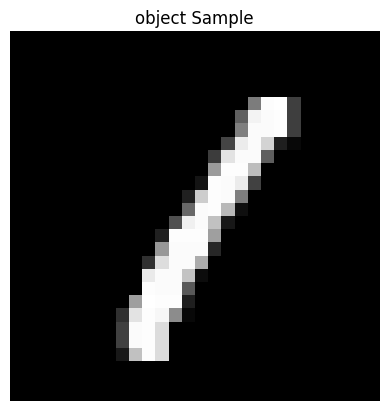

In [2]:
import torch
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from skimage.filters import threshold_otsu


IMAGE_SIZE = 28  # Fashion MNIST image size (28x28)

# Custom transformation that applies Otsu's thresholding
class OtsuBinarize(object):
    def __call__(self, image):
        image_np = image.squeeze().numpy()
        thresh = threshold_otsu(image_np)
        binary_np = (image_np > thresh).astype(np.float32)
        return torch.from_numpy(binary_np).unsqueeze(0)

# Define the transformation pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.NEAREST) #OtsuBinarize(),transforms.Normalize(mean=[0.5], std=[0.5])
])

#train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
# Get indices for samples with label 4 ("object")
desired_digits = [0,1,5]
object_indices = [i for i, (_, label) in enumerate(train_dataset) if label in desired_digits]

# Specify the number of object samples you want
n = 33 #40  # replace with any number you desire

# Select the first n object indices
selected_object_indices = object_indices[:n]

# Create a subset of the dataset containing only the selected objects
object_dataset = Subset(train_dataset, selected_object_indices)

# Optionally, create a DataLoader for the subset
train_loader = DataLoader(object_dataset, batch_size=1, shuffle=True)

# Now, train_loader will yield batches containing only object images.

import matplotlib.pyplot as plt

# Extract one sample from the object_dataset
sample, label = object_dataset[2]

# Display the image
plt.imshow(sample.squeeze(), cmap='gray')
plt.title("object Sample")
plt.axis("off")
plt.show()


192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   success
Connecting to waveshaper...   success
Applying profile...   success
Sweep complete.


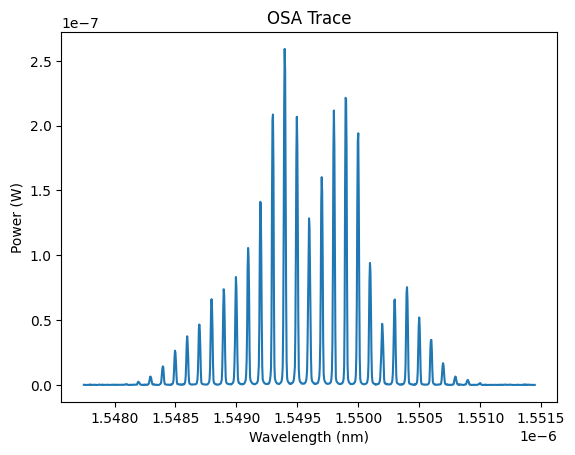

Sweep complete.


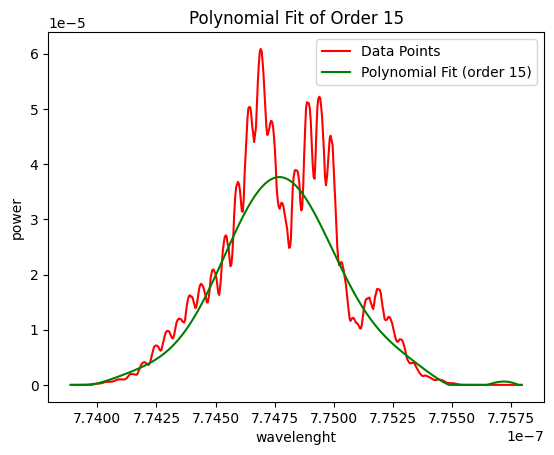

number of maximum points 30
67.76492428815114
Applying profile...   success
Sweep complete.


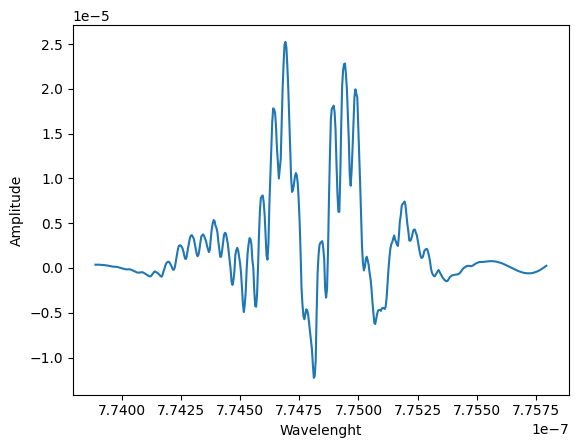

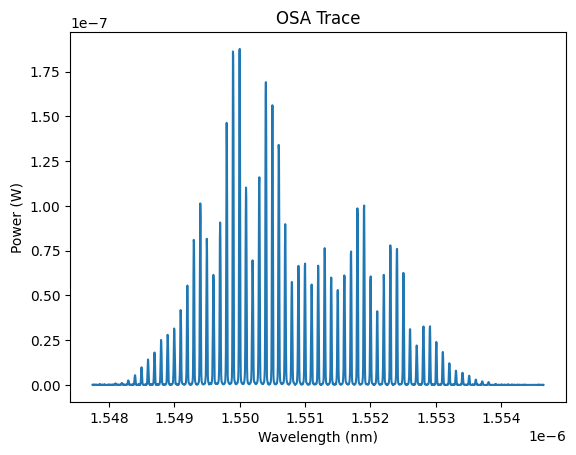

Sweep complete.


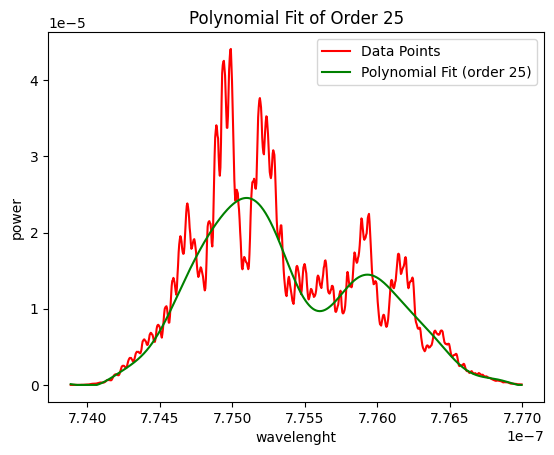

number of maximum points 60
69.85194701522556


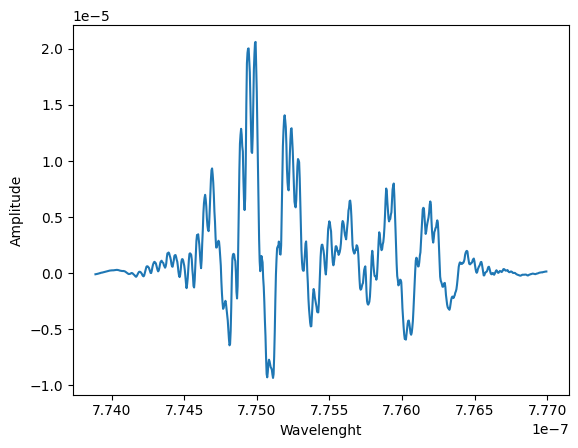

In [3]:
# Connecting to the OSA and Waveshaper, verifying correct behaviour
from osa import OSA
from pat import make_pat_func
import calibration

# === Instantiate and connect OSA ===
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()

# Create a Model
n_comblines = [16, 32]
separation_comblines = 0.2
initial_wl = 1549.598-separation_comblines*8

comblines = [np.arange(initial_wl, initial_wl + i * separation_comblines, separation_comblines) for i in n_comblines]

peaks = [np.ones(n_comblines[i]) for i in range(len(n_comblines))]
channels = [np.ones(n_comblines[i]) for i in range(len(n_comblines))]
phases = [np.zeros(n_comblines[i]) for i in range(len(n_comblines))]
initrang = [122, 122]
finrang = [600, 900]
order = [15, 25]

wavelength_trim = []
poly = []
normalization = []
fraction_m_m = []

for i in range(len(n_comblines)):
    apply_waveshaper_profile(comblines[i], peaks[i], phases[i], channels[i], plot = False)
    wavelengths, power = osa.perform_measurement_OSA(np.mean(comblines[i]), (np.max(comblines[i])-np.mean(comblines[i]))*2+0.5, 0.02, sensitivity = "high3", resolution = 0.02)
    osa.plot_trace(wavelengths, power)

    # Perform calibration
    wavelength, power, polynomial = calibration.do_calibration(osa, center=np.mean(comblines[i])/2-0.1, span=(np.max(comblines[i])-np.mean(comblines[i]))+1, order = order[i], level=2, spacing='lin')
    poly.append(polynomial)
    powerfit = polynomial(wavelength)

    calibration.plot_polynomial_fit(wavelength[initrang[i]:finrang[i]], power[initrang[i]:finrang[i]], wavelength[initrang[i]:finrang[i]], powerfit[initrang[i]:finrang[i]], order=order[i])

    prominence = power - powerfit
    prominence = prominence[initrang[i]:finrang[i]]
    wavelength = wavelength[initrang[i]:finrang[i]]
    wavelength_trim.append(wavelength)
    max_indices, _ = find_peaks(prominence, distance=5, prominence=1e-8)
    print(f'number of maximum points {len(max_indices)}')
    max_x = np.array(wavelength)[max_indices]
    max_y = np.array(prominence)[max_indices]

    fraction_max_min = np.max(max_y)/(max_y[0])
    norm = 1/(fraction_max_min*max_y[0])
    normalization.append(norm)
    fraction_m_m.append(fraction_max_min)
    
    print(fraction_max_min)
    plt.plot(wavelength,prominence)
    plt.xlabel('Wavelenght')
    plt.ylabel('Amplitude')

In [ ]:
def lambda_m(lambda_1, delta_lambda, m):
    return 1 / ((2 / lambda_1) - (m - 1) * (abs(delta_lambda) / lambda_1**2))

# Example usage
delta_lambda = separation_comblines  # Example value in nm
m = [np.arange(1,2*n_comblines[i],1) for i in range(len(n_comblines))]  # Example mode number

targets = [lambda_m(initial_wl, delta_lambda, m[i])* 1e-9 for i in range(len(n_comblines))]
print(f"λ_m = {targets}")

max_indices = [[np.argmin(np.abs(wavelength_trim[j] - t)) for t in targets[j]] for j in range(len(n_comblines))]
print(f"Indices {max_indices}")

# Custom PyTorch layer
class WaveshaperLayer(nn.Module):
    def __init__(self, osa, comblines, channels, baseline, normalization, initrang, finrang, max_indices, delta_l=0.1, sigma=0.005):
        super(WaveshaperLayer, self).__init__()
        
        self.osa = osa
        self.comblines = comblines
        self.channels = channels
        self.baseline = baseline
        self.normalization = normalization
        self.delta_l = delta_l
        self.sigma = sigma
        self.initrang = initrang
        self.finrang = finrang
        self.max_indices = max_indices
        
        self.combline_thz = [wsh.nm2thz(combline) for combline in self.comblines]
        self.rang_min = [wsh.nm2thz(combline - delta_l) for combline in self.comblines]
        self.rang_max = [wsh.nm2thz(combline + delta_l) for combline in self.comblines]
        
        self.phases = nn.Parameter(torch.zeros(len(self.comblines)))
        
    def forward(self, peaks, phases):
        phases_slice = self.phases[:peaks.shape[1]]+phases[:peaks.shape[1]]
        phases_slice = torch.squeeze(phases_slice)
        #print(f"The input is {phases_slice}")
        phase = phases_slice.cpu().numpy() if torch.is_tensor(phases_slice) else phases_slice
        #print(f"The injected phase is {phase}")
        apply_waveshaper_profile(self.comblines, peaks, phase, self.channels)

        wavelength, measurement = self.osa.perform_measurement_OSA(center=np.mean(self.comblines)/2-0.1, span=(np.max(self.comblines)-np.mean(self.comblines))+1, level=0.006, sensitivity = "high1", resolution = 0.02)
        prominence = measurement# - self.baseline(wavelength)
        prominence = calibration.set_measurement_outside_range_to_zero(wavelength, prominence, (np.min(self.comblines)/2-0.3)*1e-9, (np.max(self.comblines)/2+0.3)*1e-9)
        prominence_trim = prominence[self.initrang:self.finrang]
        
        max_y = np.array(prominence_trim)[self.max_indices]*1e8#self.normalization
        #print(f"now normalization {self.normalization}")
        #max_y = max_y/(max_y[0]*)
        max_y_tensor = torch.tensor(max_y, dtype=torch.float32)
        
        return torch.unsqueeze(max_y_tensor,0)

λ_m = [array([7.73999000e-07, 7.74049003e-07, 7.74099013e-07, 7.74149029e-07,
       7.74199052e-07, 7.74249081e-07, 7.74299116e-07, 7.74349158e-07,
       7.74399207e-07, 7.74449262e-07, 7.74499323e-07, 7.74549391e-07,
       7.74599465e-07, 7.74649546e-07, 7.74699634e-07, 7.74749727e-07,
       7.74799828e-07, 7.74849934e-07, 7.74900048e-07, 7.74950167e-07,
       7.75000294e-07, 7.75050426e-07, 7.75100566e-07, 7.75150711e-07,
       7.75200863e-07, 7.75251022e-07, 7.75301187e-07, 7.75351359e-07,
       7.75401537e-07, 7.75451722e-07, 7.75501913e-07]), array([7.73999000e-07, 7.74049003e-07, 7.74099013e-07, 7.74149029e-07,
       7.74199052e-07, 7.74249081e-07, 7.74299116e-07, 7.74349158e-07,
       7.74399207e-07, 7.74449262e-07, 7.74499323e-07, 7.74549391e-07,
       7.74599465e-07, 7.74649546e-07, 7.74699634e-07, 7.74749727e-07,
       7.74799828e-07, 7.74849934e-07, 7.74900048e-07, 7.74950167e-07,
       7.75000294e-07, 7.75050426e-07, 7.75100566e-07, 7.75150711e-07,
       7.7520

In [ ]:
layer0 = WaveshaperLayer(osa, comblines=comblines[0], channels=channels[0], baseline=poly[0], normalization=fraction_m_m[0], initrang = initrang[0], finrang = finrang[0], max_indices = max_indices[0])
layer1 = WaveshaperLayer(osa, comblines=comblines[1], channels=channels[1], baseline=poly[1], normalization=fraction_m_m[1], initrang = initrang[1], finrang = finrang[1], max_indices = max_indices[1])
physical_model0 = CustomLayer(comblines=comblines[0])
physical_model1 = CustomLayer(comblines=comblines[1])

pat_implementation0 = make_pat_func(layer0.forward, physical_model0.forward)
pat_implementation1 = make_pat_func(layer1.forward, physical_model1.forward)

LEARNING_RATE = 1e-3
EPOCHS = 30
CONDITION_DIM = 10
INPUT_DIM = IMAGE_SIZE * IMAGE_SIZE
HIDDEN_DIM1 = n_comblines[0]
LATENT_DIM = n_comblines[1]-CONDITION_DIM
HIDDEN_DIM2 =  2*n_comblines[1]-1

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(INPUT_DIM+CONDITION_DIM, HIDDEN_DIM1)  
        self.fc_mu = nn.Linear(2*HIDDEN_DIM1-1, LATENT_DIM)  
        self.fc_logvar = nn.Linear(2*HIDDEN_DIM1-1, LATENT_DIM)  
        
        # Decoder
        self.fc2 = nn.Linear(LATENT_DIM+CONDITION_DIM, LATENT_DIM+CONDITION_DIM)  
        self.fc3 = nn.Linear(HIDDEN_DIM2, INPUT_DIM)

        # Trinable parameters of kernels
        self.theta0 = nn.Parameter(torch.zeros(HIDDEN_DIM1))
        self.theta1 = nn.Parameter(torch.zeros(LATENT_DIM+CONDITION_DIM))
        self.scale_factor_mu = nn.Parameter(torch.tensor(1.0))
        self.scale_factor_logvar = nn.Parameter(torch.tensor(1.0))
        
    def encode(self, x, c):
        x = torch.cat([x, c], dim=1)
        x = self.fc1(x)
        phase = torch.where(x < 0, torch.tensor(np.pi/2, device=x.device), torch.tensor(0.0, device=x.device))
        x = torch.abs(x)
        x = pat_implementation0(x, self.theta0+phase)
        print(f"output pat0 {x}")
        mu = self.fc_mu(x)*self.scale_factor_mu
        logvar = self.fc_logvar(x)*self.scale_factor_logvar
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        print(f"mu {mu} and std {std}")
        return mu + eps * std
    
    def decode(self, z, c):
        z = torch.cat([z, c], dim=1)
        z  = self.fc2(z)
        phase = torch.where(z < 0, torch.tensor(np.pi/2, device=z.device), torch.tensor(0.0, device=z.device))
        z = torch.abs(z)
        z = pat_implementation1(z, self.theta1+phase)
        print(f"output pat1 {z}")
        return torch.sigmoid(self.fc3(z))
    
    def forward(self, x, c):
        mu, logvar = self.encode(x.view(x.size(0), -1), c) 
        z = self.reparameterize(mu, logvar) 
        return self.decode(z, c), mu, logvar 

def vae_loss(recon_x, x, mu, logvar, beta, lambda_mu):
    BCE = nn.functional.binary_cross_entropy(recon_x.view(recon_x.size(0),-1), x.view(x.size(0), -1), reduction='sum')/x.size(0)
    KLD = -torch.sum(1 + logvar - mu.pow(2) - logvar.exp())/x.size(0)
    #MU_PENALTY =  torch.sum(mu.pow(2)) / x.size(0)
    #print(f"BCE {BCE} and KLD {KLD}")
    return BCE + beta*KLD #+ lambda_mu*MU_PENALTY


Folders ensured:
- data_runs\experiment_CVAE_02\stability
- data_runs\experiment_CVAE_02\checkpoints
- data_runs\experiment_CVAE_02\traces
The injected phase is [0.        0.        1.5707964 0.        1.5707964 0.        0.
 1.5707964 0.        1.5707964 1.5707964 0.        0.        0.
 1.5707964 0.       ]
Applying profile...   success
Sweep complete.
now normalization 67.76492428815114
The injected phase is [0.        0.        1.5707964 1.5707964 1.5707964 1.5707964 0.
 0.        0.        1.5707964 1.5707964 1.5707964 0.        0.
 0.        1.5707964 0.        0.        0.        1.5707964 1.5707964
 0.        1.5707964 1.5707964 0.        0.        1.5707964 1.5707964
 0.        0.        0.        1.5707964]
Applying profile...   success
Sweep complete.
now normalization 69.85194701522556


C:\Users\ws-server\AppData\Local\Temp\ipykernel_3100\2638671648.py:105: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\Copy.cpp:308.)
  intensity[:, m[0]] = term.sum(dim=1)


The injected phase is [1.5607964 1.5607964 1.5607964 1.5807964 0.01      0.01      1.5607964
 0.01      1.5807964 0.01      0.01      1.5607964 1.5607964 1.5607964
 0.01      1.5607964]
Applying profile...   success
Sweep complete.
now normalization 67.76492428815114
The injected phase is [ 1.5607964  1.5607964  0.01       0.01       1.5807964  1.5807964
  0.01      -0.01      -0.01       1.5807964  0.01       0.01
  1.5607964 -0.01       1.5607964  1.5807964  1.5607964  1.5807964
  1.5807964  0.01      -0.01       1.5807964  1.5807964  0.01
  1.5607964 -0.01       0.01       1.5807964  1.5807964  1.5807964
  1.5807964  0.01     ]
Applying profile...   success
Sweep complete.
now normalization 69.85194701522556
The injected phase is [1.5682185  1.5681624  1.5533526  1.5737462  1.5734962  0.01744273
 1.5681634  0.00255968 1.5882391  0.00257103 0.002569   1.5682251
 1.5682293  1.568228   0.00256555 1.5682302 ]
Applying profile...   success
Sweep complete.
now normalization 67.76492428815

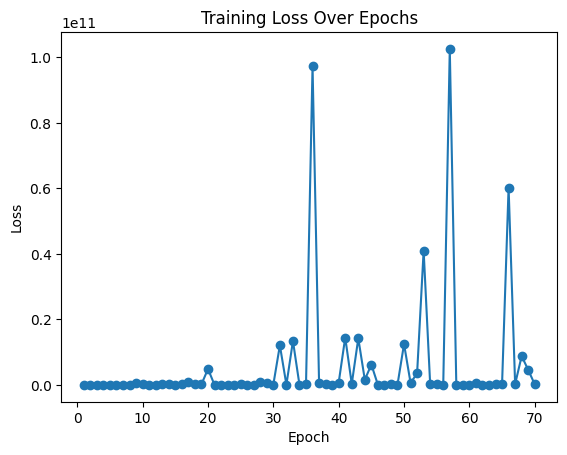

In [6]:
name_of_experiment = "experiment_CVAE_02"  # Replace with your desired folder name
create_folders(name_of_experiment)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train(model, train_loader, optimizer, epoch, loss_history, beta, lambda_mu):
    model.train()
    train_loss = 0
    for data in train_loader:
        data, labels = data
        
        condition = F.one_hot(labels, num_classes=CONDITION_DIM).float().to(device)
        recon_batch, mu, logvar = model(data, condition)
        loss = vae_loss(recon_batch, data, mu, logvar, beta, lambda_mu)

        optimizer.zero_grad()
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    avg_epoch_loss = train_loss / len(train_loader.dataset)
    loss_history.append(avg_epoch_loss)  # Store the average loss in the history

        
interval_images = 1

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

import pandas as pd  # For saving data to CSV

loss_history = []

for epoch in range(EPOCHS):
    #beta = 10000000 * (1 - np.exp(-0.02 * epoch))+1000
    beta = 10
    lambda_mu =10
    train(model, train_loader, optimizer, epoch, loss_history, beta, lambda_mu)
    avg_loss = loss_history[-1]  # Get the most recent average loss
    print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {avg_loss:.4f}")
    
    # Stop training if the loss is below the threshold
    if avg_loss < 0.01:
        print(f"Stopping early at epoch {epoch + 1} as loss < 0.001")
        break

    # Save checkpoint after each epoch (optional)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss
    }
    torch.save(checkpoint, f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint{epoch}.pth')

# Plot the loss over epochs
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.savefig(f"./data_runs/{name_of_experiment}/loss.png")
plt.show()


The injected phase is [ 1.6730608  -0.17368408  1.2756575   1.5652446   1.9183013   1.150119
 -0.05841731  1.4627914   1.6103692   0.01639367  1.8776515  -0.04487374
  1.6158168   1.0307977   1.6311302   1.703809    1.230464    0.17685822
  1.5892013   1.5185466   1.9804537  -0.05518582  1.5538592   1.4787909
  1.4714211   0.8892784   1.4945235  -0.35919583  1.24724     1.4052663
  1.668314    1.392285  ]
Applying profile...   

success
Sweep complete.
now normalization 69.85194701522556
The injected phase is [ 1.6730608   1.3971123  -0.29513884  1.5652446   0.347505   -0.42067745
 -0.05841731 -0.10800488  0.03957289  1.58719     1.8776515  -0.04487374
  0.04502045  1.0307977   1.6311302   0.13301261  1.230464    0.17685822
  1.5892013  -0.05224982  1.9804537   1.5156106   1.5538592   1.4787909
  1.4714211   0.8892784   1.4945235  -0.35919583 -0.3235564   1.4052663
  0.09751759 -0.1785114 ]
Applying profile...   success
Sweep complete.
now normalization 69.85194701522556
The injected phase is [ 0.10226437  1.3971123  -0.29513884 -0.00555187  0.347505   -0.42067745
  1.512379   -0.10800488  0.03957289  0.01639367  0.30685514 -0.04487374
  0.04502045  1.0307977   1.6311302   0.13301261 -0.3403324   0.17685822
  1.5892013  -0.05224982  0.40965736  1.5156106   1.5538592  -0.09200553
 -0.09937523  0.8892784  -0.07627285 -0.35919583 -0.3235564  -0.16553003
  0.09751759  1.392285  ]
Applying profile...   success
Swee

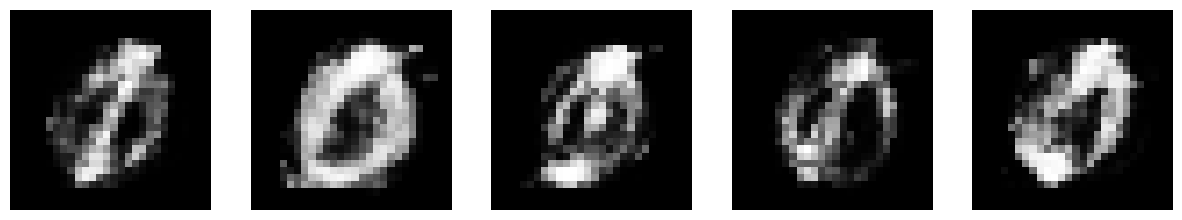

In [7]:
def generate_images(model, number_of_images, desired_digit):
    model.eval()
    samples_new = []

    with torch.no_grad():
        digit_tensor = torch.tensor([desired_digit])
        condition = F.one_hot(digit_tensor, num_classes=CONDITION_DIM).float().to(device)
        
        for i in range(number_of_images):
            z = torch.randn(1, LATENT_DIM).to(device)  # Sample random latent variables
            sample = model.decode(z, condition).cpu()            # sample shape is [784]
            # If needed, unsqueeze to add a batch dimension, so sample becomes [1, 784]
            if sample.dim() == 1:
                sample = sample.unsqueeze(0)
            samples_new.append(sample)
    
    # Stack along the batch dimension (dim=0)
    samples_new = torch.stack(samples_new, dim=0) 
    new_data = samples_new.view(number_of_images, 1, IMAGE_SIZE, IMAGE_SIZE)
    torch.save(new_data, os.path.join(f"./data_runs/{name_of_experiment}", f"new_data{desired_digit}.pt"))
    return new_data

# Generate and visualize new images
number_of_images = 5
desired_digit = 1
generated_images = generate_images(model, number_of_images, desired_digit)

# Plot the generated images
fig, axes = plt.subplots(1, number_of_images, figsize=(15, 5))
for i in range(number_of_images):
    axes[i].imshow(generated_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.savefig(f"./data_runs/{name_of_experiment}/new_image{desired_digit}.png")

plt.show()



The injected phase is [ 1.6730608  -0.17368408 -0.29513884  1.5652446   0.347505   -0.42067745
  1.512379    1.4627914   1.6103692   1.58719     1.8776515   1.5259227
  0.04502045  1.0307977   0.06033384  1.703809    1.230464    1.7476546
  1.5892013  -0.05224982  1.9804537   1.5156106   1.5538592   1.4787909
 -0.09937523  0.8892784  -0.07627285  1.2116005   1.24724     1.4052663
  1.668314   -0.1785114 ]
Applying profile...   success
Sweep complete.
now normalization 69.85194701522556
The injected phase is [ 1.6730608  -0.17368408 -0.29513884  1.5652446   1.9183013  -0.42067745
 -0.05841731  1.4627914   1.6103692   1.58719     0.30685514 -0.04487374
  0.04502045 -0.53999865  1.6311302   1.703809    1.230464    0.17685822
  1.5892013  -0.05224982  1.9804537   1.5156106   1.5538592   1.4787909
  1.4714211   0.8892784   1.4945235   1.2116005  -0.3235564   1.4052663
  1.668314    1.392285  ]
Applying profile...   success
Sweep complete.
now normalization 69.85194701522556
The injected pha

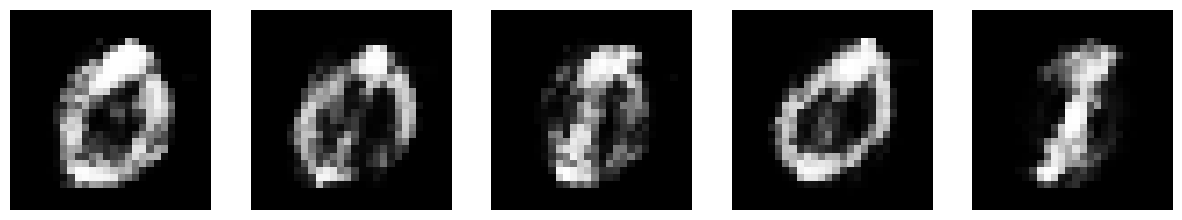

In [8]:
# Generate and visualize new images
number_of_images = 5
desired_digit = 5
generated_images = generate_images(model, number_of_images, desired_digit)

# Plot the generated images
fig, axes = plt.subplots(1, number_of_images, figsize=(15, 5))
for i in range(number_of_images):
    axes[i].imshow(generated_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.savefig(f"./data_runs/{name_of_experiment}/new_image{desired_digit}.png")

plt.show()

The injected phase is [ 0.10226437 -0.17368408 -0.29513884  1.5652446   0.347505   -0.42067745
  1.512379   -0.10800488  0.03957289  1.58719     0.30685514  1.5259227
  0.04502045 -0.53999865  0.06033384  0.13301261 -0.3403324   0.17685822
  0.01840497  1.5185466   0.40965736  1.5156106  -0.01693717  1.4787909
 -0.09937523 -0.68151796 -0.07627285  1.2116005  -0.3235564   1.4052663
  1.668314    1.392285  ]
Applying profile...   success
Sweep complete.
now normalization 69.85194701522556


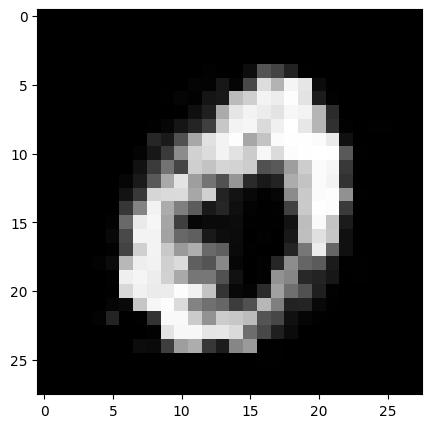

The injected phase is [ 1.6730608  -0.17368408  1.2756575   1.5652446   1.9183013   1.150119
 -0.05841731  1.4627914   1.6103692   0.01639367  1.8776515   1.5259227
  1.6158168  -0.53999865  1.6311302   1.703809    1.230464    0.17685822
  0.01840497 -0.05224982  1.9804537  -0.05518582  1.5538592   1.4787909
  1.4714211   0.8892784   1.4945235   1.2116005   1.24724     1.4052663
  1.668314    1.392285  ]
Applying profile...   success
Sweep complete.
now normalization 69.85194701522556


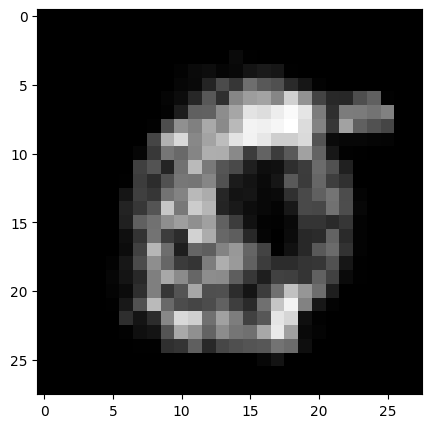

The injected phase is [ 1.6730608   1.3971123   1.2756575   1.5652446   1.9183013   1.150119
 -0.05841731  1.4627914   1.6103692   0.01639367  1.8776515  -0.04487374
  1.6158168   1.0307977   1.6311302   1.703809    1.230464    1.7476546
  1.5892013   1.5185466   0.40965736 -0.05518582  1.5538592   1.4787909
  1.4714211   0.8892784   1.4945235   1.2116005   1.24724     1.4052663
  1.668314    1.392285  ]
Applying profile...   success
Sweep complete.
now normalization 69.85194701522556


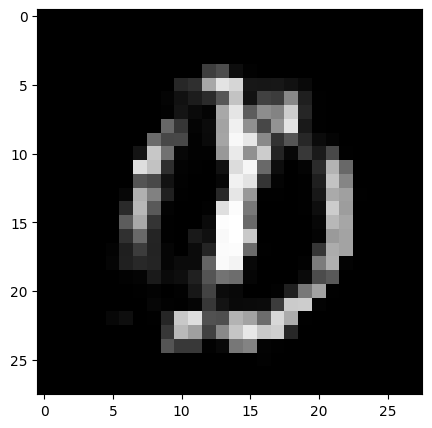

In [9]:
# Generate and visualize new images
for desired_digit in desired_digits:
    number_of_images = 1
    generated_images = generate_images(model, number_of_images, desired_digit)

    # Plot the generated images
    fig, axes = plt.subplots(1, number_of_images, figsize=(15, 5))
    plt.imshow(generated_images[0].squeeze(), cmap='gray')
    
    plt.savefig(f"./data_runs/{name_of_experiment}/new_image_individual{desired_digit}.png")

    plt.show()

In [10]:
# === Disconnect ===
disconnect_delete_waveshaper()
osa.close_connection()

Disconnecting from waveshaper...   success
Deliting waveshaper...   success
Connection closed
